# C6 Bank — Talent Intelligence: Market Intelligence
### Análise Competitiva de Vagas LinkedIn
---
**Fontes:** scraping_linkedin_1.json, scraping_linkedin_2.json, scraping_linkedin_3.json  
**Empresas monitoradas:** C6 Bank, Nubank, Itaú, XP, Bradesco, iFood, BTG Pactual, Santander  
**Total de vagas:** ~1.300


## 0. Setup

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── ESTILO C6 ─────────────────────────────────────────────────────────────────
C6_YELLOW   = '#F5C200'
C6_BLACK    = '#111111'
C6_GRAY     = '#444444'
C6_PALETTE  = ['#F5C200','#2E86AB','#A23B72','#F18F01','#C73E1D','#3B1F2B','#44BBA4','#E94F37']

plt.rcParams.update({
    'figure.facecolor':  '#111111',
    'axes.facecolor':    '#1A1A1A',
    'axes.edgecolor':    '#333333',
    'axes.labelcolor':   '#CCCCCC',
    'text.color':        '#CCCCCC',
    'xtick.color':       '#AAAAAA',
    'ytick.color':       '#AAAAAA',
    'grid.color':        '#2A2A2A',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'sans-serif',
    'axes.titlecolor':   '#FFFFFF',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'figure.titlesize':  16,
})

# ── CARREGAR DADOS ────────────────────────────────────────────────────────────
df          = pd.read_csv('../data/processed/vagas_market_intelligence.csv')
df_skills   = pd.read_csv('../data/processed/vagas_skills.csv')
df_resumo   = pd.read_csv('../data/processed/vagas_resumo.csv')
df_sk_emp   = pd.read_csv('../data/processed/vagas_skills_por_empresa.csv')

print(f"✓ Vagas carregadas: {len(df)}")
print(f"  Empresas: {sorted(df['empresa'].unique())}")
print(f"  Áreas:    {sorted(df['area'].unique())}")
print()

# Normalizar nomes de empresa — agrupa subsidiárias na holding principal
EMPRESA_MAP = {
    'F1RST Digital Services': 'Itaú Unibanco',
    'TOOLS Digital Services':  'Itaú Unibanco',
    'Banco Bradesco':          'Bradesco',
}

df['empresa']        = df['empresa'].replace(EMPRESA_MAP)
df_skills['empresa'] = df_skills['empresa'].replace(EMPRESA_MAP)

# Remover empresas fora do escopo do case
EMPRESAS_VALIDAS = [
    'C6 Bank', 'Nubank', 'Itaú Unibanco', 'XP Inc.',
    'Bradesco', 'iFood', 'BTG Pactual', 'Santander Brasil'
]
df        = df[df['empresa'].isin(EMPRESAS_VALIDAS)].copy()
df_skills = df_skills[df_skills['empresa'].isin(EMPRESAS_VALIDAS)].copy()

print(f"Empresas após normalização: {sorted(df['empresa'].unique())}")
print(f"Total vagas: {len(df)}")

df.head(3)


✓ Vagas carregadas: 1280
  Empresas: ['BTG Pactual', 'Banco Bradesco', 'C6 Bank', 'F1RST Digital Services', 'Itaú Unibanco', 'Nubank', 'Santander Brasil', 'TOOLS Digital Services', 'XP Inc.', 'iFood']
  Áreas:    ['corporativo', 'dados', 'negocios', 'operacoes', 'outros', 'tecnologia']

Empresas após normalização: ['BTG Pactual', 'Bradesco', 'C6 Bank', 'Itaú Unibanco', 'Nubank', 'Santander Brasil', 'XP Inc.', 'iFood']
Total vagas: 1280


,id,empresa,titulo,area,senioridade,modelo_trabalho,cidade,estado,pais,data_publicacao,n_candidatos,emprego_tipo,seniority_li,job_function_li,industries,easy_apply,tem_salario,link,apply_url,n_funcionarios_empresa
0,4270741879,C6 Bank,SRE | Site Reliability Engineering,tecnologia,nao_classificado,presencial,São Paulo,São Paulo,BR,2026-04-27,200,Full-time,Not Applicable,Engineering and Information Technology,Banking,False,False,https://www.linkedin.com/jobs/view/4270741879,https://job-boards.greenhouse.io/c6bank/jobs/4...,4946
1,4381518848,C6 Bank,Gerente de Vendas Cash Management Sênior | GVS,operacoes,senior,presencial,São Paulo,São Paulo,BR,2026-04-21,200,Full-time,Not Applicable,Management and Manufacturing,Banking,False,False,https://www.linkedin.com/jobs/view/4381518848,https://job-boards.greenhouse.io/c6bank/jobs/4...,4946
2,4395878275,C6 Bank,Especialista de Dados | Engenharia de Platafor...,tecnologia,especialista,presencial,São Paulo,São Paulo,BR,2026-04-22,114,Full-time,Not Applicable,Information Technology,Banking,False,False,https://www.linkedin.com/jobs/view/4395878275,https://job-boards.greenhouse.io/c6bank/jobs/4...,4946


---
## 1. Volume de Vagas por Empresa e Área
**O que revela:** intensidade de contratação por segmento e onde cada empresa está crescendo.


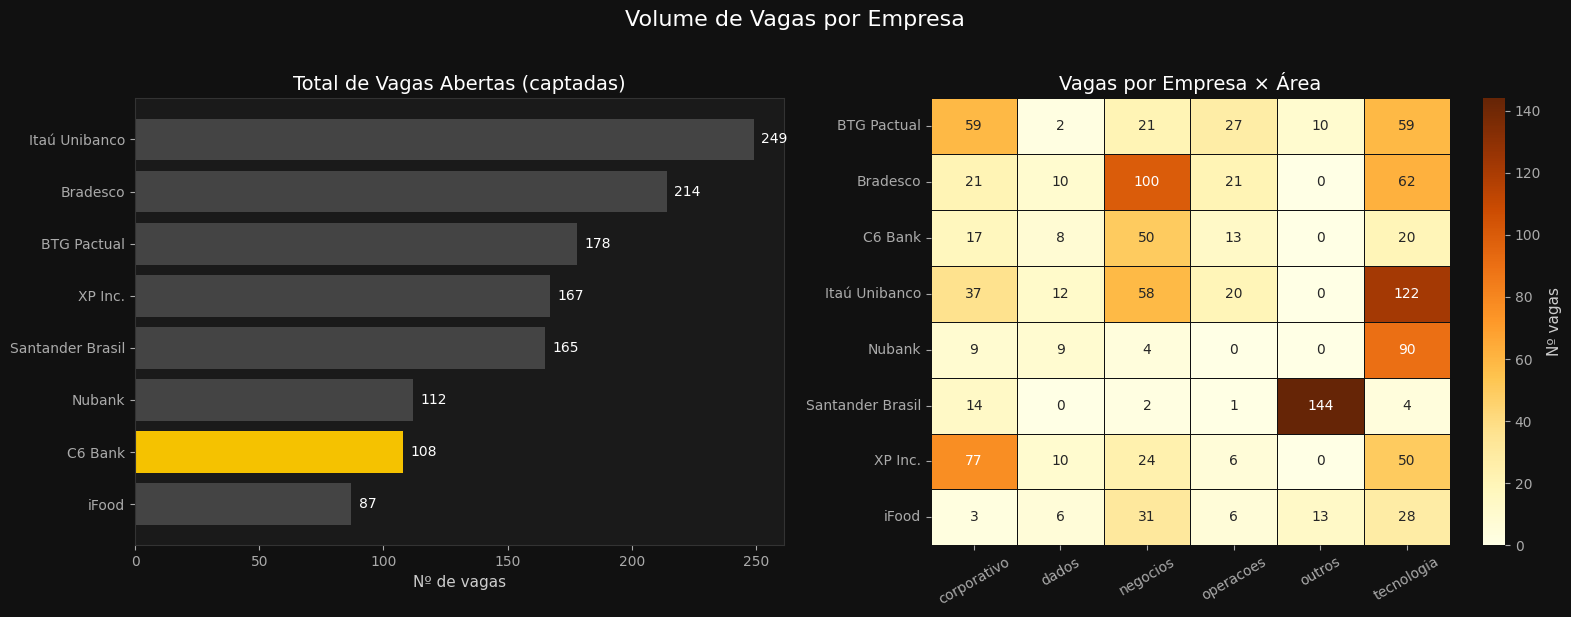


📊 Tabela detalhada:
area              corporativo  dados  negocios  operacoes  outros  tecnologia
empresa                                                                      
BTG Pactual                59      2        21         27      10          59
Bradesco                   21     10       100         21       0          62
C6 Bank                    17      8        50         13       0          20
Itaú Unibanco              37     12        58         20       0         122
Nubank                      9      9         4          0       0          90
Santander Brasil           14      0         2          1     144           4
XP Inc.                    77     10        24          6       0          50
iFood                       3      6        31          6      13          28


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Volume de Vagas por Empresa', color='white', fontsize=16, y=1.02)

# 1.1 Total por empresa
vol = df['empresa'].value_counts().sort_values()
colors = [C6_YELLOW if 'C6' in e else C6_GRAY for e in vol.index]
axes[0].barh(vol.index, vol.values, color=colors, edgecolor='none')
axes[0].set_title('Total de Vagas Abertas (captadas)')
for i, v in enumerate(vol.values):
    axes[0].text(v + 3, i, str(v), va='center', color='white', fontsize=10)
axes[0].set_xlabel('Nº de vagas')

# 1.2 Por empresa + área (heatmap)
pivot = df.groupby(['empresa', 'area']).size().unstack(fill_value=0)
sns.heatmap(pivot, ax=axes[1], cmap='YlOrBr', annot=True, fmt='d',
            linewidths=0.5, linecolor='#111111',
            cbar_kws={'label': 'Nº vagas'})
axes[1].set_title('Vagas por Empresa × Área')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n📊 Tabela detalhada:")
print(pivot.to_string())


---
## 2. Modelo de Trabalho: Remoto × Híbrido × Presencial
**Por que importa para o C6:** se o Nubank é 100% híbrido e o C6 é majoritariamente presencial,  
isso pode explicar perda de talentos seniores — modelo de trabalho é critério #1 de decisão.


Vagas por modelo de trabalho:
modelo_trabalho   hibrido  presencial  remoto  TOTAL
empresa                                             
BTG Pactual            33         142       3    178
Bradesco              127          87       0    214
C6 Bank                 3         105       0    108
Itaú Unibanco          78         166       5    249
Nubank                112           0       0    112
Santander Brasil       22         138       5    165
XP Inc.                28         138       1    167
iFood                   9          36      42     87

% por modelo de trabalho:
modelo_trabalho   hibrido  presencial  remoto
empresa                                      
BTG Pactual          18.5        79.8     1.7
Bradesco             59.3        40.7     0.0
C6 Bank               2.8        97.2     0.0
Itaú Unibanco        31.3        66.7     2.0
Nubank              100.0         0.0     0.0
Santander Brasil     13.3        83.6     3.0
XP Inc.              16.8        82.6     0.6

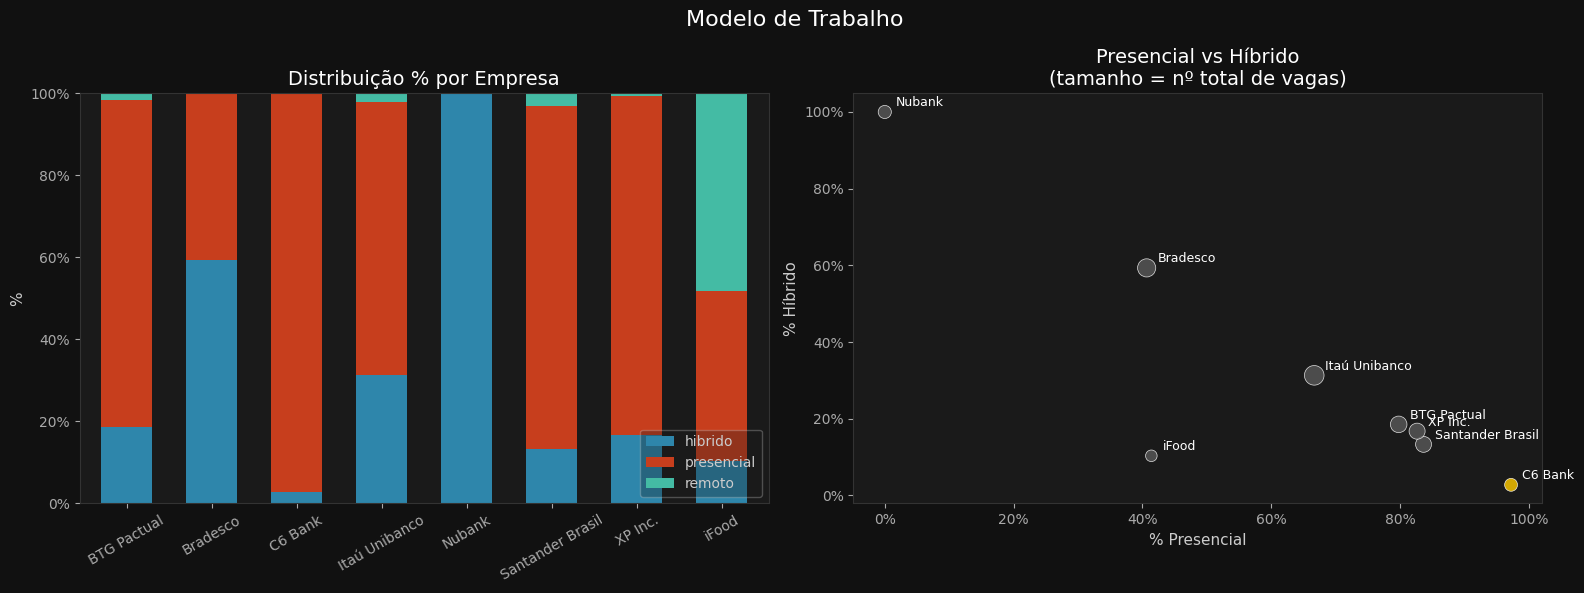

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Modelo de Trabalho', color='white', fontsize=16)

# Stacked bar
wm = df.groupby(['empresa', 'modelo_trabalho']).size().unstack(fill_value=0)
wm_pct = wm.div(wm.sum(axis=1), axis=0) * 100

colors_wm = {'hibrido': '#2E86AB', 'presencial': '#C73E1D', 
             'remoto': '#44BBA4', 'nao_informado': '#555555'}

wm_pct.plot(kind='bar', ax=axes[0], stacked=True,
            color=[colors_wm.get(c,'#888') for c in wm_pct.columns],
            edgecolor='none', width=0.6)
axes[0].set_title('Distribuição % por Empresa')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right', framealpha=0.3)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
# Destacar C6
for patch in axes[0].patches:
    pass  # empresas nos xticks

# Tabela numérica
wm_abs = wm.copy()
wm_abs['TOTAL'] = wm_abs.sum(axis=1)
print("Vagas por modelo de trabalho:")
print(wm_abs.to_string())
print()
print("% por modelo de trabalho:")
print(wm_pct.round(1).to_string())

# Bubble: presencial vs hibrido
presencial_pct = wm_pct.get('presencial', pd.Series(0, index=wm_pct.index))
hibrido_pct    = wm_pct.get('hibrido',    pd.Series(0, index=wm_pct.index))
total_vagas    = wm.sum(axis=1)

sc = axes[1].scatter(
    presencial_pct, hibrido_pct,
    s=total_vagas * 0.8,
    c=[C6_YELLOW if 'C6' in e else '#555555' for e in wm_pct.index],
    alpha=0.85, edgecolors='white', linewidths=0.5
)
for emp in wm_pct.index:
    axes[1].annotate(emp,
        (presencial_pct[emp], hibrido_pct[emp]),
        textcoords='offset points', xytext=(8, 4),
        fontsize=9, color='white')
axes[1].set_xlabel('% Presencial')
axes[1].set_ylabel('% Híbrido')
axes[1].set_title('Presencial vs Híbrido\n(tamanho = nº total de vagas)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()


---
## 3. Perfil de Senioridade
**O que revela:** o C6 está contratando mais sênior ou junior que os concorrentes?  
Alta proporção de sênior = empresa madura em determinada área.


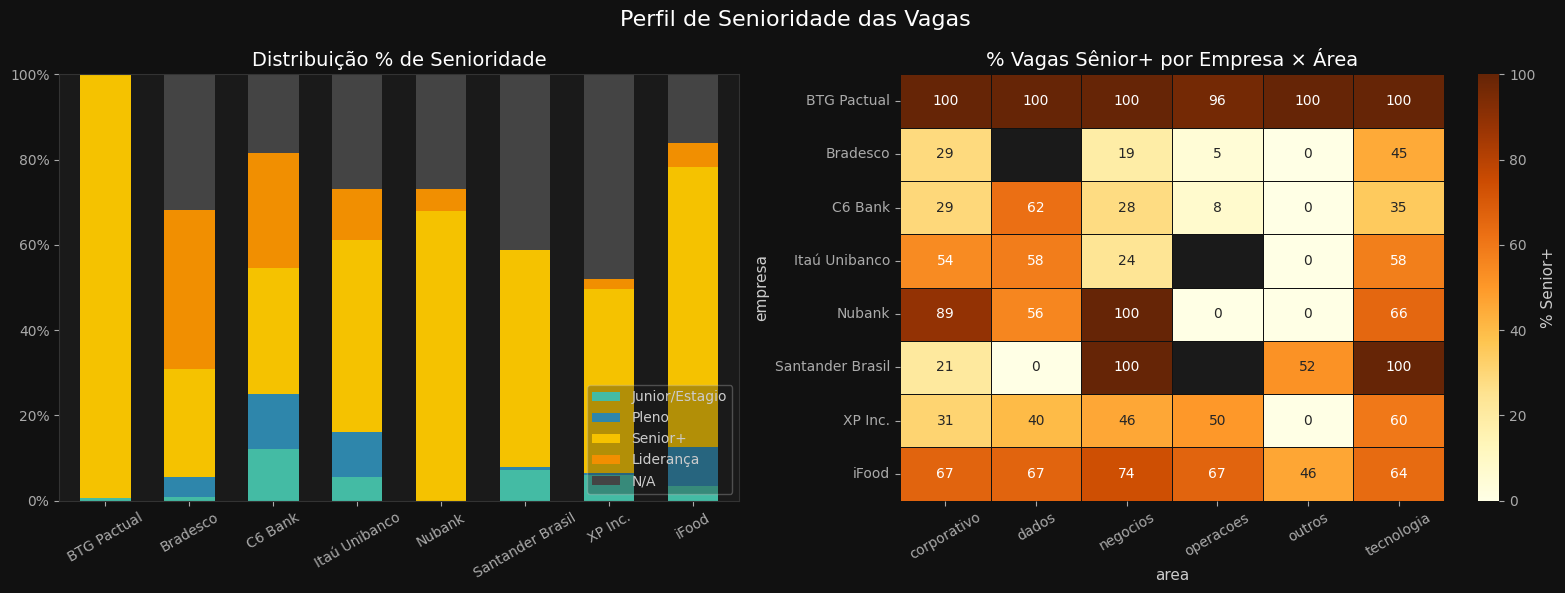


% Sênior+ por empresa:
empresa
BTG Pactual         99.438202
Bradesco            25.233645
C6 Bank             29.629630
Itaú Unibanco       44.979920
Nubank              67.857143
Santander Brasil    50.909091
XP Inc.             43.113772
iFood               65.517241
dtype: float64


In [36]:
# Simplificar categorias de senioridade
seniority_group = {
    'junior':            'Junior/Estagio',
    'estagio':           'Junior/Estagio',
    'pleno':             'Pleno',
    'senior':            'Senior+',
    'especialista':      'Senior+',
    'coordenador':       'Liderança',
    'gerente':           'Liderança',
    'diretor':           'Liderança',
    'executivo':         'Liderança',
    'vp':                'Liderança',
    'c-level':           'Liderança',
    'nao_classificado':  'N/A',
}
df['senio_grupo'] = df['senioridade'].map(seniority_group).fillna('N/A')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perfil de Senioridade das Vagas', color='white', fontsize=16)

# Stacked bar %
sen = df.groupby(['empresa', 'senio_grupo']).size().unstack(fill_value=0)
sen_pct = sen.div(sen.sum(axis=1), axis=0) * 100

order = ['Junior/Estagio','Pleno','Senior+','Liderança','N/A']
cols_present = [c for c in order if c in sen_pct.columns]
colors_sen = {'Junior/Estagio':'#44BBA4','Pleno':'#2E86AB',
              'Senior+':'#F5C200','Liderança':'#F18F01','N/A':'#444444'}

sen_pct[cols_present].plot(kind='bar', ax=axes[0], stacked=True,
    color=[colors_sen[c] for c in cols_present], edgecolor='none', width=0.6)
axes[0].set_title('Distribuição % de Senioridade')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlabel('')
axes[0].legend(loc='lower right', framealpha=0.3)

# % Sênior+ por área x empresa
sen_area = df[df['senio_grupo']=='Senior+'].groupby(['empresa','area']).size()
total_area = df.groupby(['empresa','area']).size()
pct_senior = (sen_area / total_area * 100).unstack(fill_value=0).round(1)

sns.heatmap(pct_senior, ax=axes[1], cmap='YlOrBr', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#111111',
            cbar_kws={'label': '% Senior+'})
axes[1].set_title('% Vagas Sênior+ por Empresa × Área')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\n% Sênior+ por empresa:")
print(df[df['senio_grupo']=='Senior+'].groupby('empresa').size() / df.groupby('empresa').size() * 100)


---
## 4. Skills Mais Demandadas
**O que revela:** onde o C6 está bem posicionado na comunicação técnica e onde há gaps  
em relação aos concorrentes — insumo direto para o **JD Optimizer**.


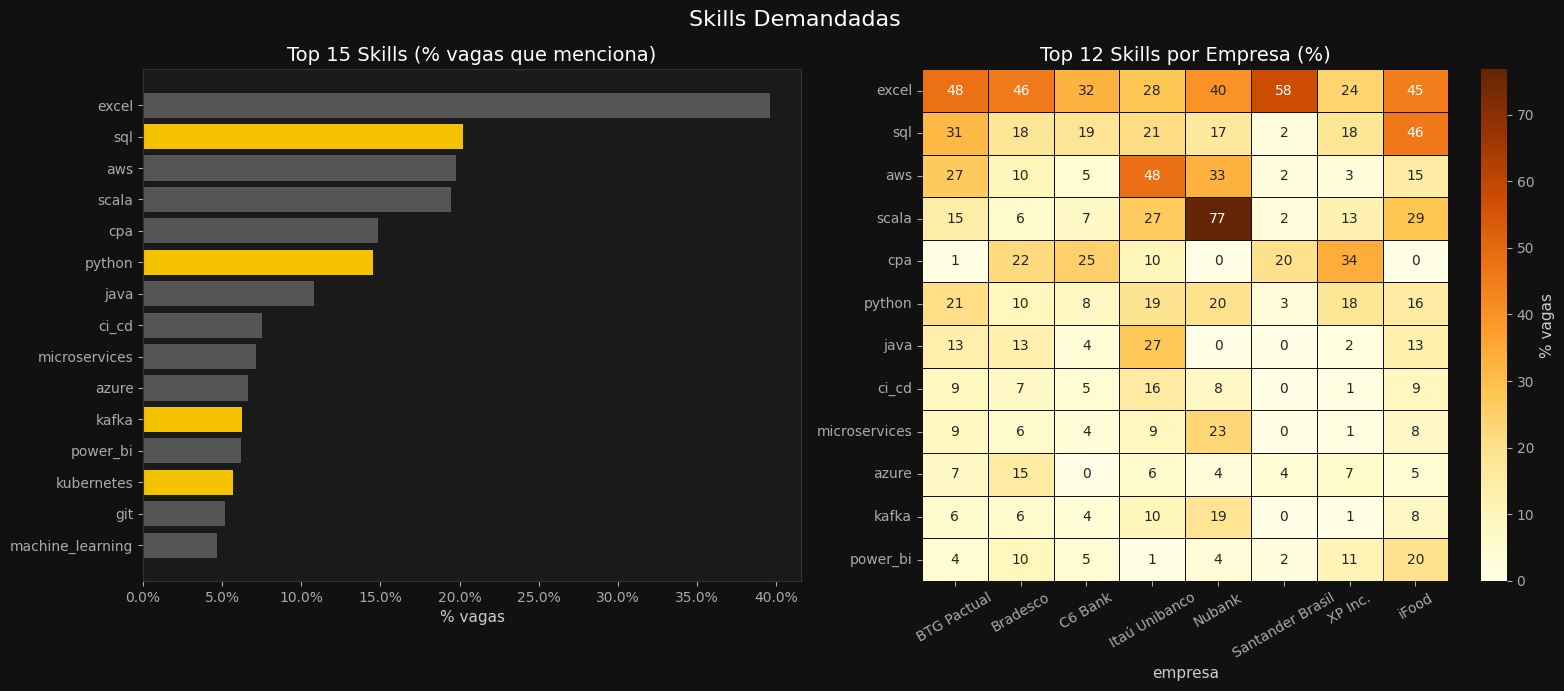

In [37]:
skill_cols = [c for c in df_skills.columns if c not in ['id','empresa','area']]

# ── 4.1 Top skills geral ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Skills Demandadas', color='white', fontsize=16)

top_skills = df_skills[skill_cols].mean().sort_values(ascending=False).head(15)
colors_sk = [C6_YELLOW if s in ['python','sql','kafka','spark','kubernetes'] else '#555555'
             for s in top_skills.index]
axes[0].barh(top_skills.index[::-1], top_skills.values[::-1] * 100,
             color=colors_sk[::-1], edgecolor='none')
axes[0].set_title('Top 15 Skills (% vagas que menciona)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlabel('% vagas')

# ── 4.2 Heatmap skills × empresa ─────────────────────────────────────────────
top10 = df_skills[skill_cols].mean().sort_values(ascending=False).head(12).index.tolist()
sk_emp = df_skills.groupby('empresa')[top10].mean() * 100

sns.heatmap(sk_emp.T, ax=axes[1], cmap='YlOrBr', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#111111',
            cbar_kws={'label': '% vagas'})
axes[1].set_title('Top 12 Skills por Empresa (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


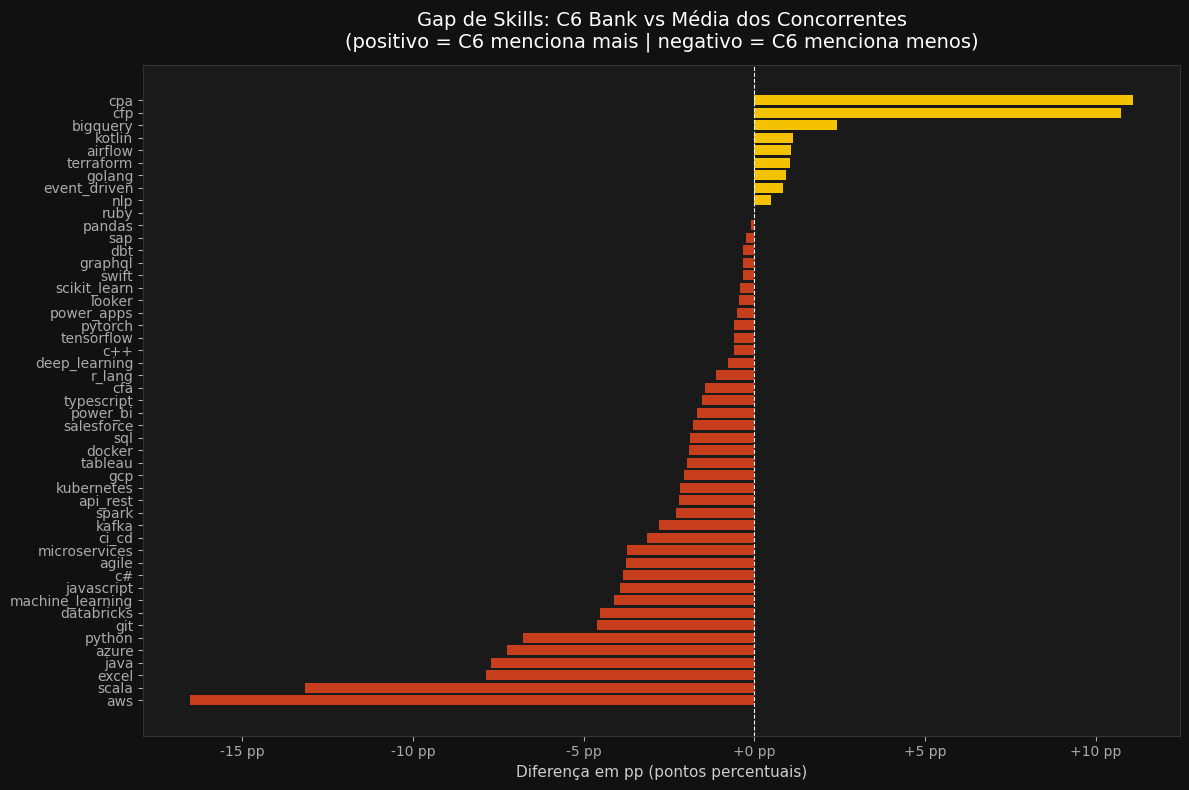


Top 5 skills onde C6 está ABAIXO do mercado:
aws     -16.53
scala   -13.16
excel    -7.87
java     -7.73
azure    -7.25

Top 5 skills onde C6 está ACIMA do mercado:
cpa         11.09
cfp         10.74
bigquery     2.44
kotlin       1.14
airflow      1.08


In [38]:
# ── 4.3 GAP C6 vs concorrentes ───────────────────────────────────────────────
# Identifica onde o C6 está abaixo da média dos concorrentes

c6_skills    = df_skills[df_skills['empresa'] == 'C6 Bank'][skill_cols].mean()
market_skills = df_skills[df_skills['empresa'] != 'C6 Bank'][skill_cols].mean()

gap = ((c6_skills - market_skills) * 100).sort_values()

fig, ax = plt.subplots(figsize=(12, 8))
colors_gap = [C6_YELLOW if v >= 0 else '#C73E1D' for v in gap.values]
ax.barh(gap.index, gap.values, color=colors_gap, edgecolor='none')
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_title('Gap de Skills: C6 Bank vs Média dos Concorrentes\n'
             '(positivo = C6 menciona mais | negativo = C6 menciona menos)',
             color='white', pad=12)
ax.set_xlabel('Diferença em pp (pontos percentuais)')
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%+.0f pp'))

plt.tight_layout()
plt.show()

print("\nTop 5 skills onde C6 está ABAIXO do mercado:")
print(gap.head(5).round(2).to_string())
print("\nTop 5 skills onde C6 está ACIMA do mercado:")
print(gap.tail(5).sort_values(ascending=False).round(2).to_string())


---
## 5. Pressão de Candidatos por Vaga
**O que revela:** onde há mais disputa por talentos. Alta concorrência de candidatos  
em vagas técnicas sinaliza melhor qualidade de candidatura do que em vagas abertas.


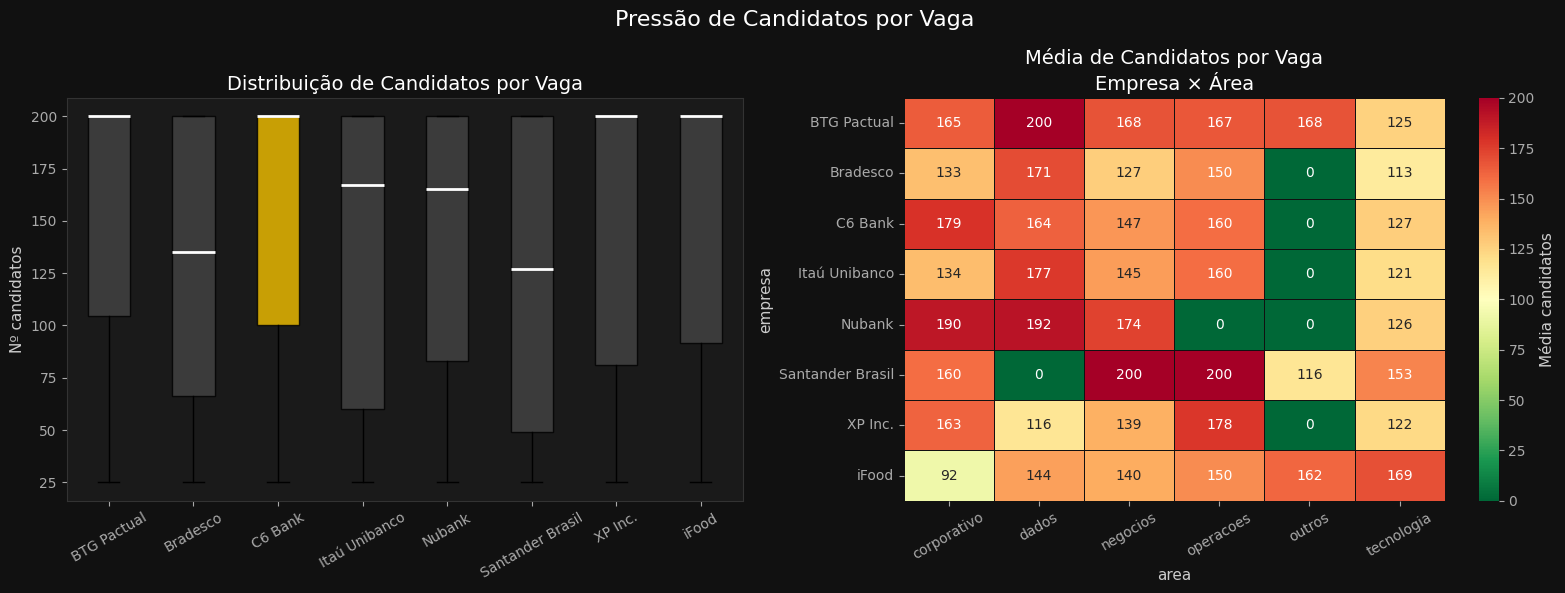


Média de candidatos por empresa:
                   mean  median  max
empresa                             
BTG Pactual       153.0   200.0  200
Bradesco          128.0   135.0  200
C6 Bank           151.0   200.0  200
Itaú Unibanco     134.0   167.0  200
Nubank            138.0   165.0  200
Santander Brasil  122.0   127.0  200
XP Inc.           145.0   200.0  200
iFood             152.0   200.0  200


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pressão de Candidatos por Vaga', color='white', fontsize=16)

# Boxplot por empresa
data_box = [df[df['empresa'] == emp]['n_candidatos'].dropna().values
            for emp in sorted(df['empresa'].unique())]
empresas_box = sorted(df['empresa'].unique())

bp = axes[0].boxplot(data_box, labels=empresas_box, patch_artist=True,
                      medianprops={'color':'white','linewidth':2})
for patch, emp in zip(bp['boxes'], empresas_box):
    patch.set_facecolor(C6_YELLOW if 'C6' in emp else '#444444')
    patch.set_alpha(0.8)
axes[0].set_title('Distribuição de Candidatos por Vaga')
axes[0].set_ylabel('Nº candidatos')
axes[0].tick_params(axis='x', rotation=30)

# Média por empresa + área
cands = df.groupby(['empresa','area'])['n_candidatos'].mean().unstack(fill_value=0).round(0)
sns.heatmap(cands, ax=axes[1], cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#111111',
            cbar_kws={'label': 'Média candidatos'})
axes[1].set_title('Média de Candidatos por Vaga\nEmpresa × Área')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nMédia de candidatos por empresa:")
print(df.groupby('empresa')['n_candidatos'].agg(['mean','median','max']).round(0).to_string())


---
## 6. Sinais de Employer Branding nas Vagas
**Easy Apply, repostagem e modelo de trabalho** são sinais de estratégia de atração.  
- Easy Apply = barreira baixa → mais volume, menos qualidade  
- Alta repostagem = dificuldade de preenchimento ou posição recorrente


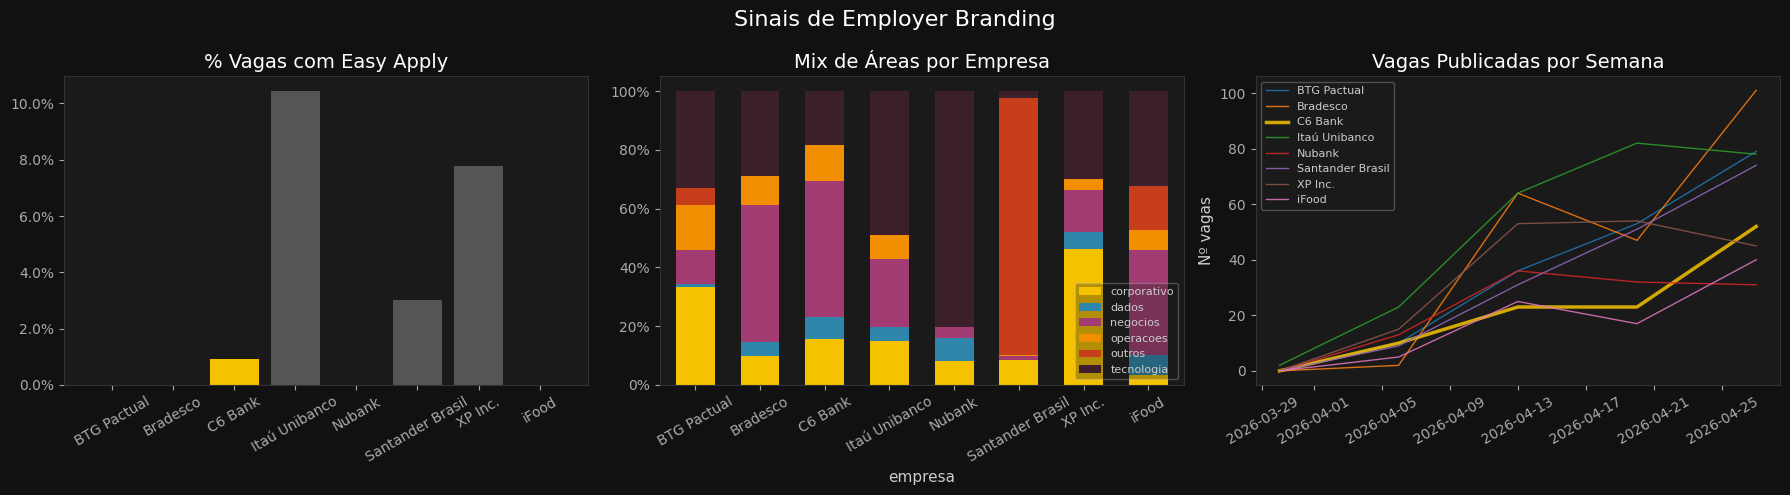

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sinais de Employer Branding', color='white', fontsize=16)

# Easy Apply
ea = df.groupby('empresa')['easy_apply'].mean() * 100
colors_ea = [C6_YELLOW if 'C6' in e else '#555555' for e in ea.index]
axes[0].bar(ea.index, ea.values, color=colors_ea, edgecolor='none')
axes[0].set_title('% Vagas com Easy Apply')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# Vagas por área (proporção)
area_pct = df.groupby(['empresa','area']).size().unstack(fill_value=0)
area_pct_norm = area_pct.div(area_pct.sum(axis=1), axis=0) * 100
area_pct_norm.plot(kind='bar', ax=axes[1], stacked=True,
                   color=C6_PALETTE[:len(area_pct_norm.columns)],
                   edgecolor='none', width=0.6)
axes[1].set_title('Mix de Áreas por Empresa')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='lower right', framealpha=0.3, fontsize=8)

# Vagas por tempo (série temporal)
df['data_pub'] = pd.to_datetime(df['data_publicacao'], errors='coerce')
df_time = df.dropna(subset=['data_pub'])
df_time['semana'] = df_time['data_pub'].dt.to_period('W').dt.start_time
time_emp = df_time.groupby(['semana','empresa']).size().unstack(fill_value=0)
for emp in time_emp.columns:
    color = C6_YELLOW if 'C6' in emp else None
    lw    = 2.5 if 'C6' in emp else 1
    axes[2].plot(time_emp.index, time_emp[emp], label=emp,
                 color=color, linewidth=lw, alpha=0.85)
axes[2].set_title('Vagas Publicadas por Semana')
axes[2].set_ylabel('Nº vagas')
axes[2].legend(fontsize=8, framealpha=0.3)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
## 7. Radar C6 Bank vs Concorrentes
Comparativo multidimensional de posicionamento.


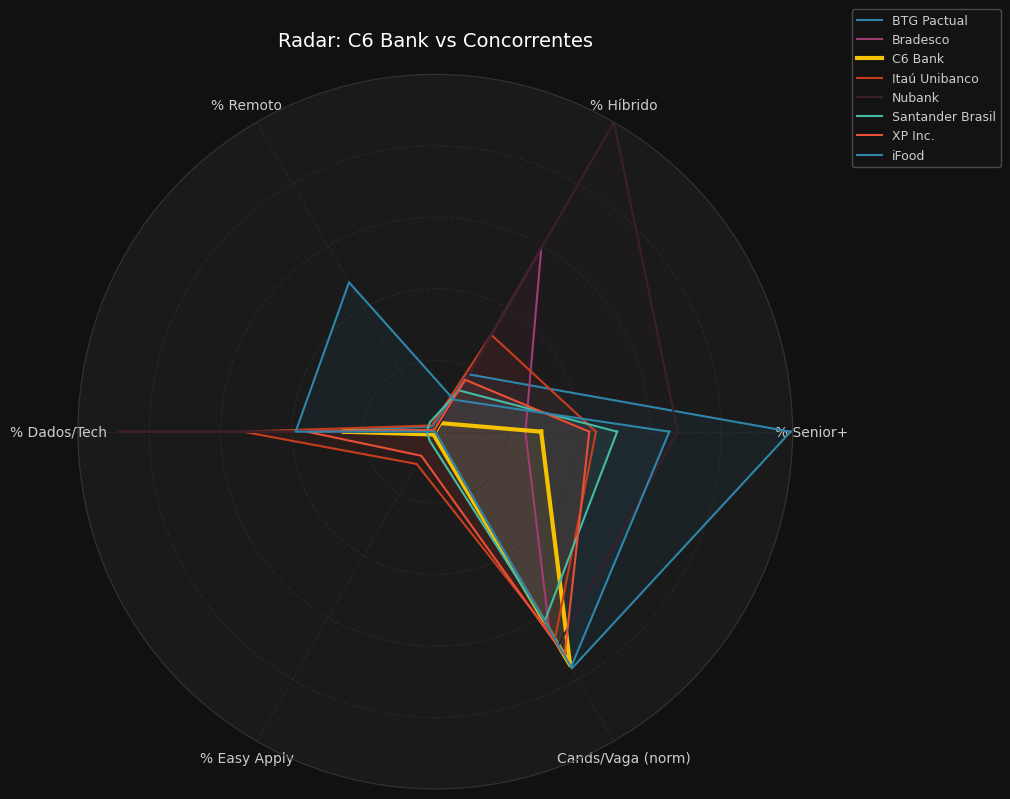

In [41]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Métricas normalizadas 0-1 para o radar
def get_metrics(empresa_df, all_df):
    n = len(empresa_df)
    return {
        '% Senior+':        (empresa_df['senio_grupo']=='Senior+').mean(),
        '% Híbrido':        (empresa_df['modelo_trabalho']=='hibrido').mean(),
        '% Remoto':         (empresa_df['modelo_trabalho']=='remoto').mean(),
        '% Dados/Tech':     empresa_df['area'].isin(['tecnologia','dados']).mean(),
        '% Easy Apply':     empresa_df['easy_apply'].mean(),
        'Cands/Vaga (norm)':(empresa_df['n_candidatos'].mean() / all_df['n_candidatos'].max()),
    }

empresas_radar = sorted(df['empresa'].unique())
metrics_all = {emp: get_metrics(df[df['empresa']==emp], df) for emp in empresas_radar}

cats  = list(list(metrics_all.values())[0].keys())
N     = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'polar': True})
ax.set_facecolor('#1A1A1A')
fig.set_facecolor('#111111')

for i, (emp, metrics) in enumerate(metrics_all.items()):
    values = list(metrics.values()) + [list(metrics.values())[0]]
    non_c6_palette = C6_PALETTE[1:] if len(C6_PALETTE) > 1 else [C6_GRAY]
    color = C6_YELLOW if 'C6' in emp else non_c6_palette[i % len(non_c6_palette)]
    lw     = 3 if 'C6' in emp else 1.5
    ax.plot(angles, values, color=color, linewidth=lw, label=emp)
    ax.fill(angles, values, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, color='#CCCCCC', fontsize=10)
ax.set_yticklabels([])
ax.set_ylim(0, 1)
ax.grid(color='#333333', linestyle='--')
ax.spines['polar'].set_color('#333333')
ax.set_title('Radar: C6 Bank vs Concorrentes', 
             color='white', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1),
          framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.show()


---
## 8. Resumo Executivo — Principais Insights


In [43]:
print("=" * 60)
print("INSIGHTS DE MARKET INTELLIGENCE — C6 BANK")
print("=" * 60)

c6  = df[df['empresa'] == 'C6 Bank']
mkt = df[df['empresa'] != 'C6 Bank']

# 1. Modelo de trabalho
c6_presencial = (c6['modelo_trabalho'] == 'presencial').mean() * 100
mkt_presencial = (mkt['modelo_trabalho'] == 'presencial').mean() * 100
print(f"\n1. MODELO DE TRABALHO")
print(f"   C6 Bank:    {c6_presencial:.0f}% presencial vs {100-c6_presencial:.0f}% híbrido/remoto")
print(f"   Mercado:    {mkt_presencial:.0f}% presencial vs {100-mkt_presencial:.0f}% híbrido/remoto")
print(f"   → GAP: C6 é {c6_presencial - mkt_presencial:+.0f}pp mais presencial que o mercado")

# 2. Senioridade
c6_senior  = (c6['senio_grupo'] == 'Senior+').mean() * 100
mkt_senior = (mkt['senio_grupo'] == 'Senior+').mean() * 100
print(f"\n2. PERFIL DE SENIORIDADE")
print(f"   C6 Bank:    {c6_senior:.0f}% vagas Sênior+")
print(f"   Mercado:    {mkt_senior:.0f}% vagas Sênior+")

# 3. Skills gap
c6_sk   = df_skills[df_skills['empresa']=='C6 Bank'][skill_cols].mean()
mkt_sk  = df_skills[df_skills['empresa']!='C6 Bank'][skill_cols].mean()
gap     = (c6_sk - mkt_sk).sort_values()
print(f"\n3. SKILLS — MAIORES GAPS")
print("   C6 ABAIXO do mercado:")
for sk, v in gap.head(5).items():
    print(f"     {sk:<20} {v*100:+.1f} pp")
print("   C6 ACIMA do mercado:")
for sk, v in gap.tail(5).sort_values(ascending=False).items():
    print(f"     {sk:<20} {v*100:+.1f} pp")

# 4. Candidatos
c6_cands  = c6['n_candidatos'].mean()
mkt_cands = mkt['n_candidatos'].mean()
print(f"\n4. PRESSÃO DE CANDIDATOS")
print(f"   C6 Bank:    {c6_cands:.0f} candidatos/vaga em média")
print(f"   Mercado:    {mkt_cands:.0f} candidatos/vaga em média")

# 5. Easy Apply
c6_ea  = c6['easy_apply'].mean() * 100
mkt_ea = mkt['easy_apply'].mean() * 100
print(f"\n5. EASY APPLY")
print(f"   C6 Bank:    {c6_ea:.0f}% das vagas")
print(f"   Mercado:    {mkt_ea:.0f}% das vagas")

print("\n" + "=" * 60)


INSIGHTS DE MARKET INTELLIGENCE — C6 BANK

1. MODELO DE TRABALHO
   C6 Bank:    97% presencial vs 3% híbrido/remoto
   Mercado:    60% presencial vs 40% híbrido/remoto
   → GAP: C6 é +37pp mais presencial que o mercado

2. PERFIL DE SENIORIDADE
   C6 Bank:    30% vagas Sênior+
   Mercado:    54% vagas Sênior+

3. SKILLS — MAIORES GAPS
   C6 ABAIXO do mercado:
     aws                  -16.5 pp
     scala                -13.2 pp
     excel                -7.9 pp
     java                 -7.7 pp
     azure                -7.3 pp
   C6 ACIMA do mercado:
     cpa                  +11.1 pp
     cfp                  +10.7 pp
     bigquery             +2.4 pp
     kotlin               +1.1 pp
     airflow              +1.1 pp

4. PRESSÃO DE CANDIDATOS
   C6 Bank:    151 candidatos/vaga em média
   Mercado:    137 candidatos/vaga em média

5. EASY APPLY
   C6 Bank:    1% das vagas
   Mercado:    4% das vagas



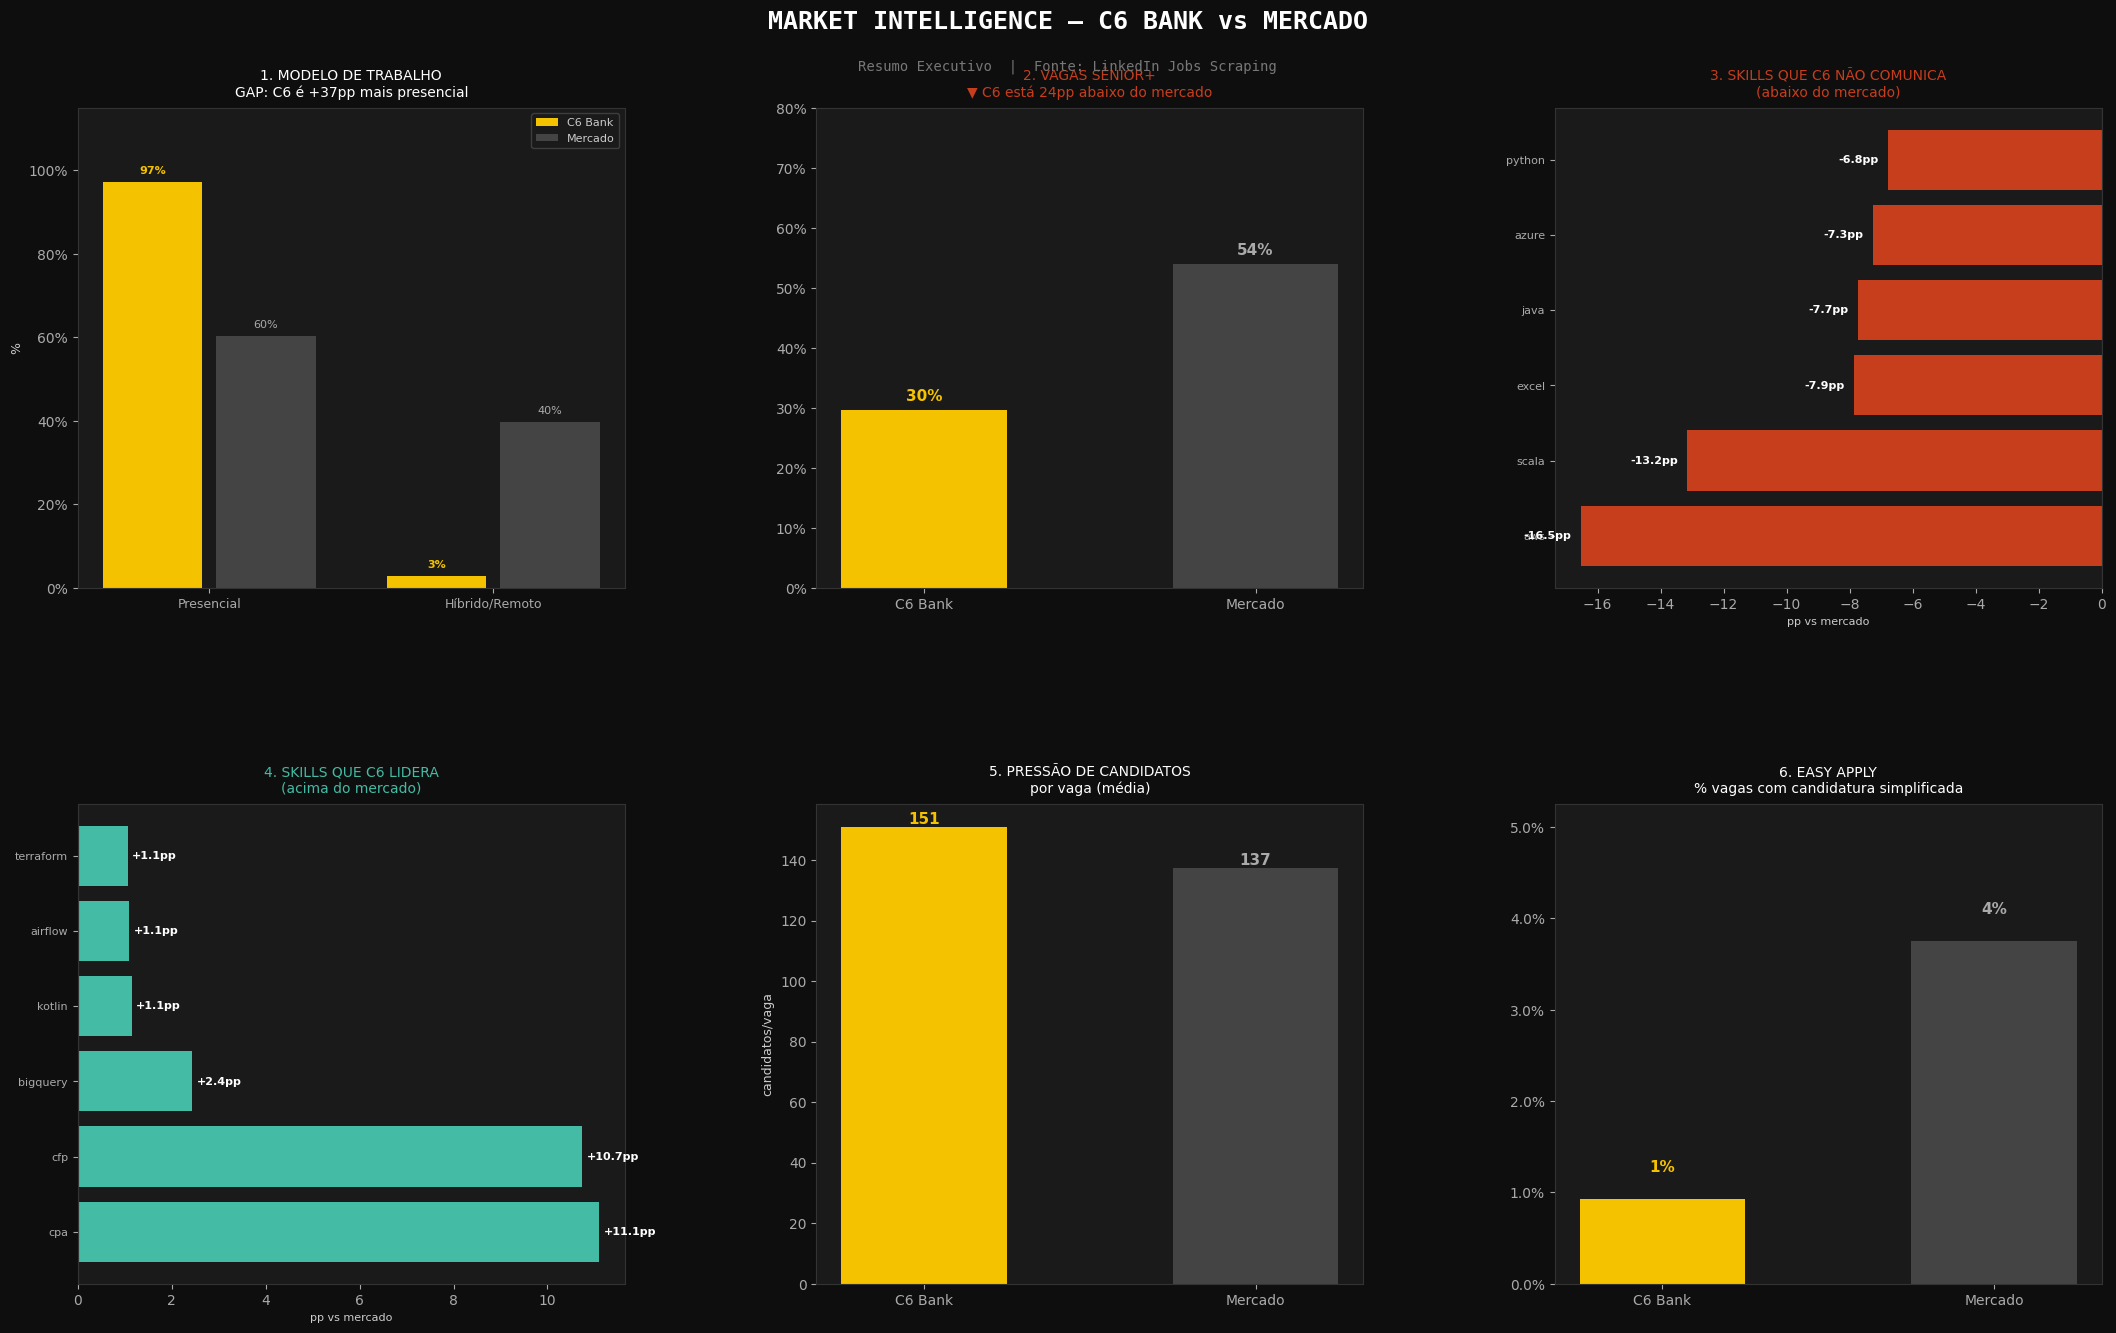

In [44]:
c6  = df[df['empresa'] == 'C6 Bank']
mkt = df[df['empresa'] != 'C6 Bank']

# ── Calcular métricas ─────────────────────────────────────────────────────────
c6_presencial  = (c6['modelo_trabalho'] == 'presencial').mean() * 100
mkt_presencial = (mkt['modelo_trabalho'] == 'presencial').mean() * 100
c6_hibrido     = (c6['modelo_trabalho'] == 'hibrido').mean() * 100
mkt_hibrido    = (mkt['modelo_trabalho'] == 'hibrido').mean() * 100

c6_senior  = (c6['senio_grupo'] == 'Senior+').mean() * 100
mkt_senior = (mkt['senio_grupo'] == 'Senior+').mean() * 100

c6_sk  = df_skills[df_skills['empresa']=='C6 Bank'][skill_cols].mean()
mkt_sk = df_skills[df_skills['empresa']!='C6 Bank'][skill_cols].mean()
gap    = (c6_sk - mkt_sk).sort_values()
gap_bottom = gap.head(6)
gap_top    = gap.tail(6).sort_values(ascending=False)

c6_cands  = c6['n_candidatos'].mean()
mkt_cands = mkt['n_candidatos'].mean()

c6_ea  = c6['easy_apply'].mean() * 100
mkt_ea = mkt['easy_apply'].mean() * 100

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0E0E0E')

# Título principal
fig.text(0.5, 0.97, 'MARKET INTELLIGENCE — C6 BANK vs MERCADO',
         ha='center', va='top', fontsize=18, fontweight='bold',
         color='white', family='monospace')
fig.text(0.5, 0.935, 'Resumo Executivo  |  Fonte: LinkedIn Jobs Scraping',
         ha='center', va='top', fontsize=10, color='#777777', family='monospace')

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                      left=0.05, right=0.97, top=0.90, bottom=0.06)

BAR_KW = dict(edgecolor='none', width=0.5)
C6_COL = '#F5C200'
MK_COL = '#444444'
UP_COL = '#44BBA4'
DN_COL = '#C73E1D'

# ── 1. Modelo de trabalho ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Presencial', 'Híbrido/Remoto']
c6_vals  = [c6_presencial,  100 - c6_presencial]
mkt_vals = [mkt_presencial, 100 - mkt_presencial]
x = np.arange(2)
ax1.bar(x - 0.2, c6_vals,  0.35, color=C6_COL, label='C6 Bank',  **{k:v for k,v in BAR_KW.items() if k!='width'})
ax1.bar(x + 0.2, mkt_vals, 0.35, color=MK_COL, label='Mercado',  **{k:v for k,v in BAR_KW.items() if k!='width'})
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('%', fontsize=9); ax1.set_ylim(0, 115)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
for xi, (cv, mv) in enumerate(zip(c6_vals, mkt_vals)):
    ax1.text(xi - 0.2, cv + 2, f'{cv:.0f}%', ha='center', fontsize=8, color=C6_COL, fontweight='bold')
    ax1.text(xi + 0.2, mv + 2, f'{mv:.0f}%', ha='center', fontsize=8, color='#AAAAAA')
ax1.set_title(f'1. MODELO DE TRABALHO\nGAP: C6 é {c6_presencial-mkt_presencial:+.0f}pp mais presencial',
              fontsize=10, color='white', pad=8)
ax1.legend(fontsize=8, framealpha=0.2)

# ── 2. Senioridade ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(['C6 Bank', 'Mercado'], [c6_senior, mkt_senior],
               color=[C6_COL, MK_COL], **BAR_KW)
ax2.set_ylim(0, 80)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, [c6_senior, mkt_senior]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1.5,
             f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold',
             color=C6_COL if val == c6_senior else '#AAAAAA')
gap_sen = c6_senior - mkt_senior
arrow = '▼' if gap_sen < 0 else '▲'
color_arrow = DN_COL if gap_sen < 0 else UP_COL
ax2.set_title(f'2. VAGAS SÊNIOR+\n{arrow} C6 está {abs(gap_sen):.0f}pp abaixo do mercado',
              fontsize=10, color=color_arrow, pad=8)

# ── 3. Gap de skills (negativo) ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.barh(gap_bottom.index, gap_bottom.values * 100, color=DN_COL, edgecolor='none')
ax3.axvline(0, color='#555', linewidth=0.8)
ax3.set_xlabel('pp vs mercado', fontsize=8)
for i, (sk, v) in enumerate(gap_bottom.items()):
    ax3.text(v * 100 - 0.3, i, f'{v*100:.1f}pp', ha='right', va='center',
             fontsize=8, color='white', fontweight='bold')
ax3.set_title('3. SKILLS QUE C6 NÃO COMUNICA\n(abaixo do mercado)',
              fontsize=10, color=DN_COL, pad=8)
ax3.tick_params(axis='y', labelsize=8)

# ── 4. Gap de skills (positivo) ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.barh(gap_top.index, gap_top.values * 100, color=UP_COL, edgecolor='none')
ax4.axvline(0, color='#555', linewidth=0.8)
ax4.set_xlabel('pp vs mercado', fontsize=8)
for i, (sk, v) in enumerate(gap_top.items()):
    ax4.text(v * 100 + 0.1, i, f'+{v*100:.1f}pp', ha='left', va='center',
             fontsize=8, color='white', fontweight='bold')
ax4.set_title('4. SKILLS QUE C6 LIDERA\n(acima do mercado)',
              fontsize=10, color=UP_COL, pad=8)
ax4.tick_params(axis='y', labelsize=8)

# ── 5. Candidatos por vaga ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(['C6 Bank', 'Mercado'], [c6_cands, mkt_cands],
                color=[C6_COL, MK_COL], **BAR_KW)
for bar, val in zip(bars5, [c6_cands, mkt_cands]):
    ax5.text(bar.get_x() + bar.get_width()/2, val + 1,
             f'{val:.0f}', ha='center', fontsize=11, fontweight='bold',
             color=C6_COL if val == c6_cands else '#AAAAAA')
ax5.set_ylabel('candidatos/vaga', fontsize=9)
ax5.set_title('5. PRESSÃO DE CANDIDATOS\npor vaga (média)',
              fontsize=10, color='white', pad=8)

# ── 6. Easy Apply ─────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
bars6 = ax6.bar(['C6 Bank', 'Mercado'], [c6_ea, mkt_ea],
                color=[C6_COL, MK_COL], **BAR_KW)
ax6.set_ylim(0, max(c6_ea, mkt_ea) * 1.4)
ax6.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars6, [c6_ea, mkt_ea]):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 0.3,
             f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold',
             color=C6_COL if val == c6_ea else '#AAAAAA')
ax6.set_title('6. EASY APPLY\n% vagas com candidatura simplificada',
              fontsize=10, color='white', pad=8)

plt.show()